# M3: Exploratory Data Analysis

**Author:** Parvathy Krishna A

**Issues:** 8, 9, 10

This notebook implements:
- **Issue 8:** Numerical Analysis
- **Issue 9:** Genre and Language Analysis
- **Issue 10:** Relationship and Correlation Analysis

The analysis uses the cleaned TMDB dataset and follows the visualization style and analysis code used in the main notebook.


## Load Data


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("tmdb_clean.csv", parse_dates=["release_date"])
import ast
df["genres"] = df["genres"].apply(ast.literal_eval)
df["release_year"] = df["release_date"].dt.year
df["low_votes"] = df["vote_count"] < 20


---
# Issue 8: Numerical Analysis

Analyze the distributions of ratings, vote counts and popularity, including skewness and the effect of filtering low-vote movies.


## 8.1 Distribution Analysis


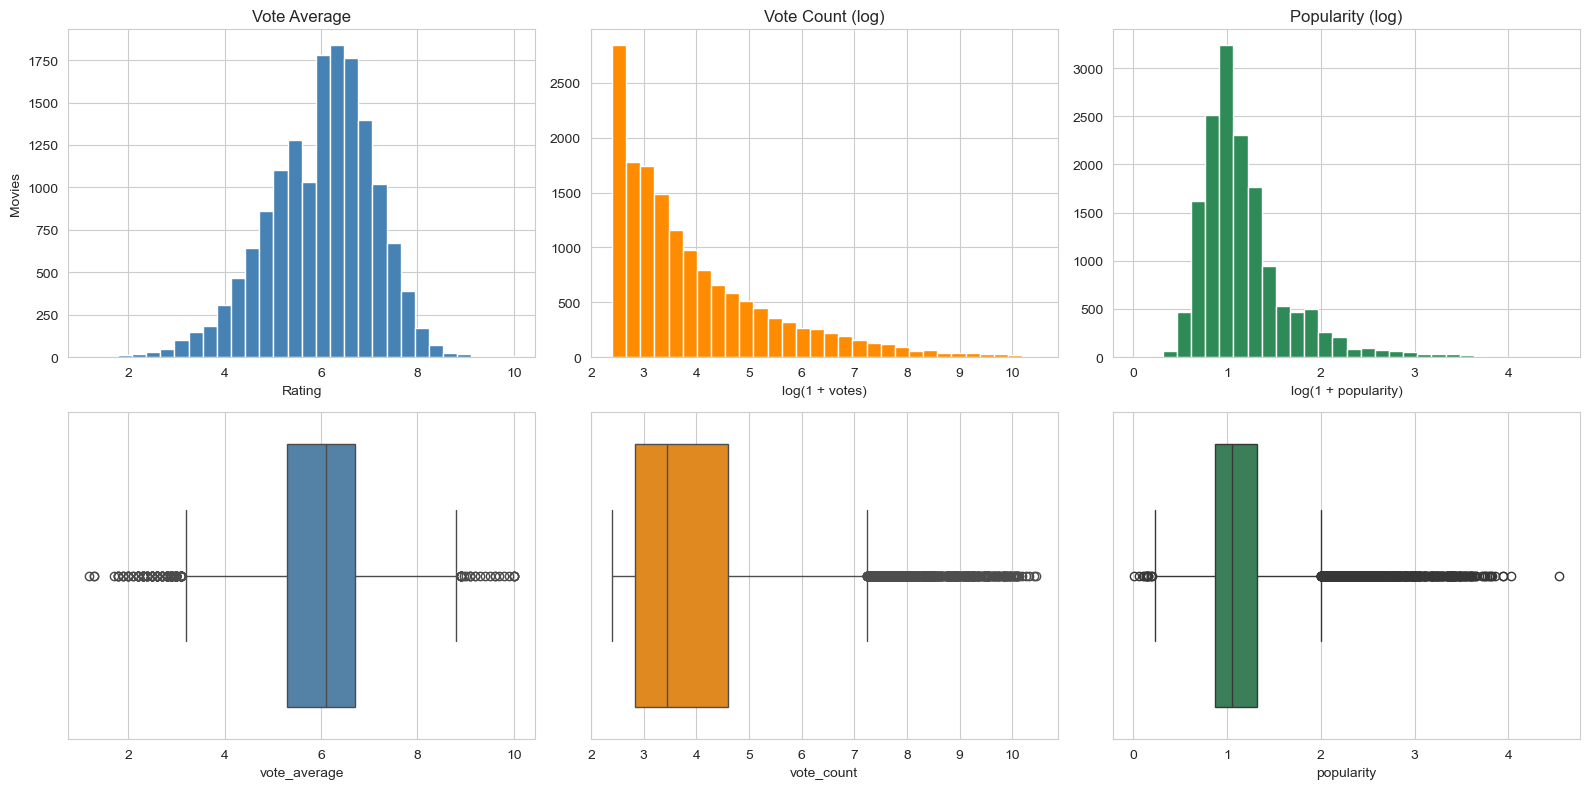

        vote_average  vote_count  popularity
mean            6.00      331.45        2.77
median          6.10       30.00        1.88
skew           -0.45       10.24        6.85

Rating stats, all vs vote_count>=20:
       all  votes>=20
mean  6.00       6.12
std   1.08       0.99


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

fig, ax = plt.subplots(2, 3, figsize=(16, 8))
ax[0,0].hist(df["vote_average"], bins=30, color="steelblue", edgecolor="white")
ax[0,0].set(title="Vote Average", xlabel="Rating", ylabel="Movies")
ax[0,1].hist(np.log1p(df["vote_count"]), bins=30, color="darkorange", edgecolor="white")
ax[0,1].set(title="Vote Count (log)", xlabel="log(1 + votes)")
ax[0,2].hist(np.log1p(df["popularity"]), bins=30, color="seagreen", edgecolor="white")
ax[0,2].set(title="Popularity (log)", xlabel="log(1 + popularity)")
sns.boxplot(x=df["vote_average"], ax=ax[1,0], color="steelblue")
sns.boxplot(x=np.log1p(df["vote_count"]), ax=ax[1,1], color="darkorange")
sns.boxplot(x=np.log1p(df["popularity"]), ax=ax[1,2], color="seagreen")
plt.tight_layout(); plt.show()

print(df[["vote_average", "vote_count", "popularity"]].agg(["mean", "median", "skew"]).round(2))
print("\nRating stats, all vs vote_count>=20:")
print(df["vote_average"].describe().round(2)[["mean", "std"]].to_frame("all").join(
      df[~df["low_votes"]]["vote_average"].describe().round(2)[["mean", "std"]].to_frame("votes>=20")))

### Findings

- The mean vote average is **6.00**, with a median of **6.10**, showing that ratings are centered around 6.
- Vote count is strongly right-skewed (**skew = 10.24**), so most movies have relatively few votes while a smaller number have very high vote counts.
- Popularity is also strongly right-skewed (**skew = 6.85**).
- The vote-average distribution is slightly left-skewed (**skew = -0.45**).
- After restricting the analysis to movies with at least 20 votes, the mean rating increases from **6.00 to 6.12**, while the standard deviation decreases from **1.08 to 0.99**.


---
# Issue 9: Genre and Language Analysis

Compare movie volume, average rating and average popularity across genres and the top 10 original languages.


## 9.1 Genre Analysis


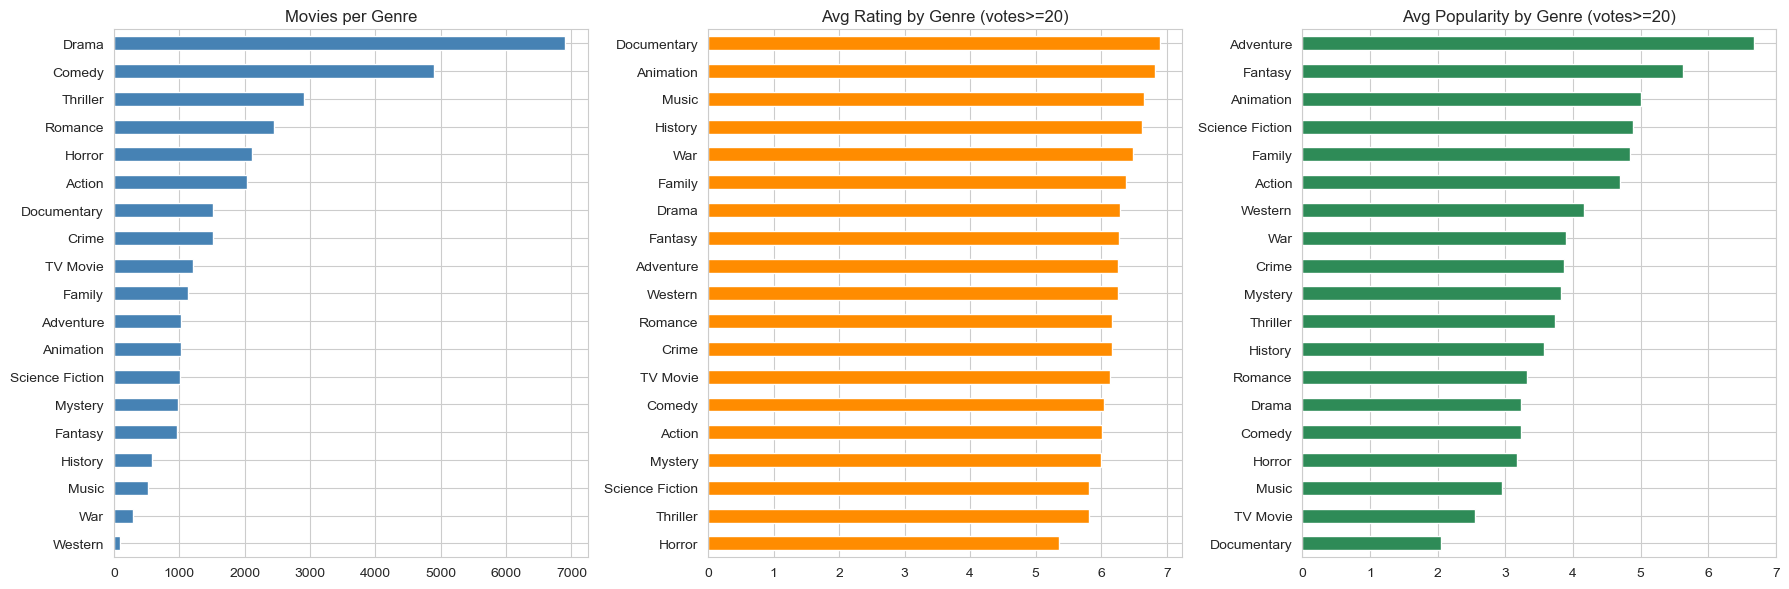

                 movies  avg_rating  avg_pop
genres                                      
Documentary        1515        6.89     2.05
Animation          1021        6.82     5.00
Music               518        6.65     2.95
History             587        6.62     3.57
War                 293        6.49     3.89
Family             1130        6.38     4.84
Drama              6910        6.29     3.24
Fantasy             963        6.27     5.62
Adventure          1028        6.26     6.67
Western              99        6.26     4.16
Romance            2450        6.17     3.32
Crime              1510        6.17     3.87
TV Movie           1216        6.13     2.56
Comedy             4898        6.04     3.23
Action             2033        6.01     4.70
Mystery             984        6.00     3.82
Science Fiction    1006        5.82     4.89
Thriller           2905        5.81     3.74
Horror             2117        5.36     3.18


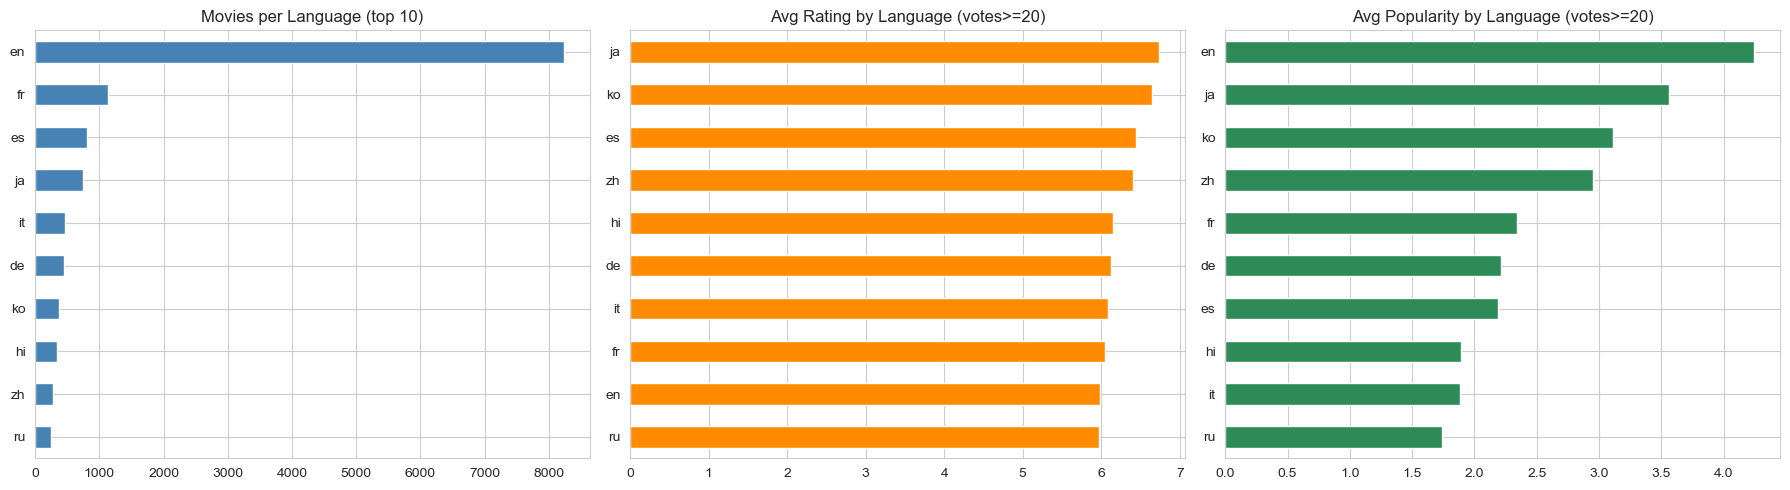

                   movies  avg_rating  avg_pop
original_language                             
ja                    751        6.73     3.56
ko                    377        6.65     3.11
es                    806        6.44     2.19
zh                    270        6.41     2.95
hi                    340        6.15     1.89
de                    443        6.12     2.21
it                    457        6.08     1.88
fr                   1138        6.05     2.34
en                   8229        5.99     4.24
ru                    248        5.97     1.74


In [6]:
g = df.explode("genres")
gr = g[~g["low_votes"]]

gs = pd.DataFrame({
    "movies": g["genres"].value_counts(),
    "avg_rating": gr.groupby("genres")["vote_average"].mean().round(2),
    "avg_pop": gr.groupby("genres")["popularity"].mean().round(2)
}).sort_values("avg_rating")

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
gs["movies"].sort_values().plot(kind="barh", ax=ax[0], color="steelblue", title="Movies per Genre")
gs["avg_rating"].plot(kind="barh", ax=ax[1], color="darkorange", title="Avg Rating by Genre (votes>=20)")
gs["avg_pop"].sort_values().plot(kind="barh", ax=ax[2], color="seagreen", title="Avg Popularity by Genre (votes>=20)")
for a in ax: a.set_ylabel("")
plt.tight_layout(); plt.show()
print(gs.sort_values("avg_rating", ascending=False))

top = df["original_language"].value_counts().head(10).index
lr = df[~df["low_votes"] & df["original_language"].isin(top)]
ls = pd.DataFrame({
    "movies": df[df["original_language"].isin(top)]["original_language"].value_counts(),
    "avg_rating": lr.groupby("original_language")["vote_average"].mean().round(2),
    "avg_pop": lr.groupby("original_language")["popularity"].mean().round(2)
}).sort_values("avg_rating")

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ls["movies"].sort_values().plot(kind="barh", ax=ax[0], color="steelblue", title="Movies per Language (top 10)")
ls["avg_rating"].plot(kind="barh", ax=ax[1], color="darkorange", title="Avg Rating by Language (votes>=20)")
ls["avg_pop"].sort_values().plot(kind="barh", ax=ax[2], color="seagreen", title="Avg Popularity by Language (votes>=20)")
for a in ax: a.set_ylabel("")
plt.tight_layout(); plt.show()
print(ls.sort_values("avg_rating", ascending=False))

### Findings — Genre Analysis

- **Drama** has the largest number of movies (**6,910**), followed by Comedy and Thriller.
- **Documentary** has the highest average rating (**6.89**) among genres with at least 20 votes.
- **Horror** has the lowest average rating (**5.36**).
- **Adventure** has the highest average popularity (**6.67**), followed by Fantasy (**5.62**).
- The genre results show that the most common genres are not necessarily the highest-rated or most popular genres.


## 9.2 Language Analysis

The same analysis is applied to the ten most frequent original languages.


### Findings — Language Analysis

- **English** has by far the largest number of movies (**8,229**).
- **Japanese (ja)** has the highest average rating among the top 10 languages (**6.73**).
- **Russian (ru)** has the lowest average rating in this comparison (**5.97**).
- English has the highest average popularity (**4.24**) among the top 10 languages.
- The language comparison highlights that dataset volume, rating and popularity do not necessarily move together.


---
# Issue 10: Relationship and Correlation Analysis

Examine relationships between ratings, vote counts, popularity and release year using Spearman correlation, hexbin plots, decade-level boxplots and yearly trends.


## 10.1 Spearman Correlation Analysis


In [2]:
d = df.copy()
d["log_pop"] = np.log1p(d["popularity"])
d["log_votes"] = np.log1p(d["vote_count"])
d["decade"] = (d["release_year"] // 10 * 10).astype(str) + "s"
rel = d[~d["low_votes"]]
cols = ["vote_average", "log_votes", "log_pop", "release_year"]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(d[cols].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[0])
ax[0].set_title("Spearman Correlation (all movies)")
sns.heatmap(rel[cols].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[1])
ax[1].set_title("Spearman Correlation (votes>=20)")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hexbin(d["log_votes"], d["vote_average"], gridsize=40, cmap="Blues", mincnt=1)
ax[0].set(title="Vote Count vs Rating", xlabel="log(1 + votes)", ylabel="Vote Average")
ax[1].hexbin(d["log_pop"], d["vote_average"], gridsize=40, cmap="Greens", mincnt=1)
ax[1].set(title="Popularity vs Rating", xlabel="log(1 + popularity)", ylabel="Vote Average")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=rel, x="decade", y="vote_average", ax=ax[0], color="steelblue")
ax[0].set_title("Rating by Decade (votes>=20)")
yr = rel.groupby("release_year")[["vote_average", "popularity"]].mean()
ax[1].plot(yr.index, yr["vote_average"], color="darkorange", label="Avg rating")
ax2 = ax[1].twinx(); ax2.plot(yr.index, yr["popularity"], color="seagreen", label="Avg popularity")
ax[1].set(title="Yearly Avg Rating and Popularity (votes>=20)", xlabel="Year", ylabel="Rating")
ax2.set_ylabel("Popularity")
plt.tight_layout(); plt.show()

print(d[cols].corr(method="spearman").round(2))
print(rel[cols].corr(method="spearman").round(2))
print(rel.groupby("decade")["vote_average"].agg(["count", "mean"]).round(2))

NameError: name 'df' is not defined

### Findings

- Vote count and popularity have the strongest relationship: **Spearman correlation = 0.65** for all movies and **0.68** for movies with at least 20 votes.
- Vote average has a weak positive relationship with log vote count (**0.23** all movies; **0.24** with votes ≥ 20).
- Vote average has a weaker positive relationship with log popularity (**0.16** in both datasets).
- Release year has very weak relationships with the other variables, with correlations close to zero.
- The correlation structure is broadly similar before and after the 20-vote filter.


## 10.2 Relationship and Temporal Analysis

The same Issue 10 code also visualizes vote count versus rating, popularity versus rating, ratings by decade, and yearly average rating and popularity.


### Findings

- The hexbin plots show that most movies cluster around ratings of approximately **5–7**, particularly at lower vote counts and popularity levels.
- For movies with at least 20 votes, the mean rating is **6.06** in both the 2000s and 2010s.
- The mean rating rises to **6.33** in the 2020s.
- The yearly plot shows variation in both average rating and popularity over time.


---
# Summary

## Issue 8: Numerical Analysis
- Examined distributions of vote average, vote count and popularity.
- Applied log transformation to vote count and popularity for distribution analysis.
- Compared rating statistics before and after the 20-vote reliability filter.

## Issue 9: Genre and Language Analysis
- Compared movie counts, average ratings and average popularity by genre.
- Compared the same measures across the top 10 original languages.
- Applied the 20-vote filter for rating and popularity comparisons.

## Issue 10: Relationship and Correlation Analysis
- Calculated Spearman correlations for ratings, log votes, log popularity and release year.
- Used hexbin plots to examine rating relationships with votes and popularity.
- Compared ratings across decades and examined yearly rating/popularity trends.


In [3]:
print("M3 Exploratory Data Analysis Complete!")


M3 Exploratory Data Analysis Complete!
